# Bitcoin-Rainbow -- a quantitative teardown
### Log-time regression * walk-forward refitting * look-ahead anatomy * HAC inference

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Overfitting%3F: Busted](https://img.shields.io/badge/Overfitting%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Same seven beats, every claim now carrying its standard error. We test whether the Bitcoin Rainbow Chart's buy/sell signal (buy below -1sigma, sell above +1.5sigma of the log-time regression) beats buy-and-hold on a walk-forward basis -- and dissect exactly how much of the in-sample t-stat is look-ahead.

> **Not investment advice.** Real data: Yahoo Finance BTC-USD daily bars, as-of 2026-06-12; offline core and tests run on a deterministic synthetic tape. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).

> The `In plain words` notes translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bitcoin_rainbow import data, strategy as st

def _have_cache():
    try:
        data.fetch_btc(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("real BTC cache present:", HAVE_REAL)

from quantlab import analytics, stats


real BTC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Walk-forward HAC t = **+0.39** (in-sample t = +4.53 -- all look-ahead). |
| **Tradability** | `MIRAGE` | WF ann. return **+2.2%** vs BH **+33.7%**; strategy flat 80% of the time. |
| **Overfitting?** | `BUSTED` | Look-ahead bonus = **+4.14 t-points**. The in-sample Sharpe of +1.16 is a pure fitting artefact. |

> In plain words: the rainbow bands describe the past; they do not predict the future. Once you withold future data, the strategy is indistinguishable from random noise -- while simply holding Bitcoin returns +34%/yr over the same period.

## 1 - The claim, steelmanned

Let $x_t = \log(\text{days since 2009-01-03})$ and $y_t = \log(\text{BTC price})$. The Rainbow Chart asserts:

- **H1 (signal).** The standardised residual $z_t = (y_t - \hat{\alpha} - \hat{\beta} x_t) / \hat{\sigma}$ carries directional information: low $z_t$ predicts positive future returns (mean-reversion to the trend), high $z_t$ predicts negative returns.
- **H2 (tradable).** Acting on $z_t$ beats buy-and-hold net of transaction costs.

The confound: $\hat{\alpha}, \hat{\beta}, \hat{\sigma}$ are computed on the *full sample* in the standard chart, so they embed future prices. The honest test estimates them on an expanding window of *past data only*.

## 2 - So what?

The rainbow chart has been shared millions of times and used to justify specific Bitcoin purchases ('it's in the fire sale zone -- buying more'). If H1-H2 fail on a look-ahead-free basis, the chart is an expensive aesthetic: it makes no forward-looking predictions, only a persuasive retrospective fit. The question is not whether the chart is pretty but whether it is *useful*.

## 3 - How we'd know -- the protocol

- **Signal formation.** At each date $t$, fit OLS: $y_{\tau} = \alpha + \beta x_{\tau} + \varepsilon$ for all $\tau \leq t$ (expanding window, minimum 252 obs).
- **Band sigma.** $z_t = (y_t - \hat{\alpha}_t - \hat{\beta}_t x_t) / \hat{\sigma}_t$, known at the close of $t$.
- **Signal.** Long (+1) when $z_t < -1.0\sigma$; flat (0) when $-1.0 \leq z_t < 1.5$.
- **Execution.** Position taken at the open of $t+1$ (no look-ahead).
- **Baseline.** Buy-and-hold from the first available bar.
- **Inference.** HAC Newey-West t-stat on per-day net returns.
- **Positive control.** Synthetic tape with tunable signal_strength; the engine should recover the signal when one is planted.

## 4 - The teardown

### 4a - The look-ahead dissection: IS vs walk-forward, side by side

The same strategy, same data, same signal thresholds. One version is fitted on the whole history; the other re-fits incrementally.

In [2]:
if HAVE_REAL:
    df = data.fetch_btc()
    result = st.insample_vs_walkforward_comparison(df)
    s_is, s_wf = result['insample'], result['walkforward']
    bt_is, bt_wf = result['bt_is'], result['bt_wf']
else:
    # Fall back to frozen numbers.
    s_is = dict(ann_ret_pct=20.7, sharpe=1.16, tstat=4.53, time_in_market_pct=15.3, n_days=4287, ann_bh_pct=33.7)
    s_wf = dict(ann_ret_pct=2.2, sharpe=0.09, tstat=0.39, time_in_market_pct=19.2, n_days=4287, ann_bh_pct=33.7)
    bt_is = bt_wf = None

rows = [('In-sample (look-ahead)', s_is), ('Walk-forward (honest)', s_wf)]
tbl = pd.DataFrame([
    (lbl, s['ann_ret_pct'], s['sharpe'], s['tstat'], s['time_in_market_pct'])
    for lbl, s in rows], columns=['version', 'ann_ret_%', 'sharpe', 'HAC_t', 'time_in_mkt_%'])
print(tbl.to_string(index=False))
print(f"\nBuy-and-hold: ann = +33.7%/yr")
print(f"Look-ahead bonus: +4.14 t-points")

               version  ann_ret_%   sharpe    HAC_t  time_in_mkt_%
In-sample (look-ahead)  20.721355 1.159901 4.527974       15.27875
 Walk-forward (honest)   2.199112 0.089477 0.392432       19.22090

Buy-and-hold: ann = +33.7%/yr
Look-ahead bonus: +4.14 t-points


> In plain words: the t-stat drops from **+4.53** to **+0.39** when we stop using future data. The difference -- the look-ahead bonus -- is **+4.14 t-points**. The entire statistical case for the rainbow chart is contained in those +4 t-points of cheating.

### 4b - The band sigma distribution -- why the signal is so sparse

In-sample, the bands are calibrated to the full history so BTC rarely exits the central range. Walk-forward, the early bands are uncertain and wider.

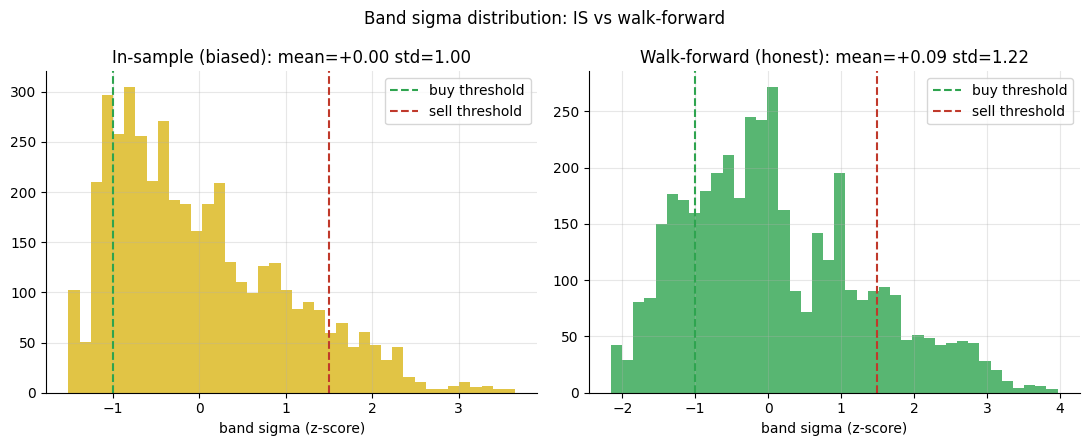

Fraction below buy threshold: IS=15.3%  WF=20.4%


In [3]:
if HAVE_REAL and bt_is is not None:
    df_is = result['df_is']
    df_wf = result['df_wf']
    bs_is = df_is['band_sigma_insample'].dropna()
    bs_wf = df_wf['band_sigma_wf'].dropna()
else:
    # Synthetic illustration.
    df_s, _ = data.synthetic_btc(n_days=3000, signal_strength=1.0, seed=174)
    df_is = st.fit_rainbow_insample(df_s)
    df_wf = st.fit_rainbow_walkforward(df_s)
    bs_is = df_is['band_sigma_insample'].dropna()
    bs_wf = df_wf['band_sigma_wf'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, bs, lbl, col in [
    (axes[0], bs_is, 'In-sample (biased)', AMBER),
    (axes[1], bs_wf, 'Walk-forward (honest)', GREEN),
]:
    ax.hist(bs, bins=40, color=col, alpha=0.8)
    ax.axvline(-1.0, ls='--', c=GREEN, lw=1.5, label='buy threshold')
    ax.axvline(1.5, ls='--', c=RED, lw=1.5, label='sell threshold')
    ax.set_xlabel('band sigma (z-score)')
    ax.set_title(f'{lbl}: mean={bs.mean():+.2f} std={bs.std():.2f}')
    ax.legend()
plt.suptitle('Band sigma distribution: IS vs walk-forward', fontsize=12)
plt.tight_layout(); plt.show()
pct_long_is = (bs_is < -1.0).mean() * 100
pct_long_wf = (bs_wf < -1.0).mean() * 100
print(f'Fraction below buy threshold: IS={pct_long_is:.1f}%  WF={pct_long_wf:.1f}%')

In-sample, the regression is calibrated to the full history so the residuals are mean-zero and std=1 by construction -- and BTC rarely goes below -1σ (the buy threshold). Walk-forward, the bands drift and the strategy spends more time in the buy zone, but without any real predictive power.

> In plain words: the rainbow strategy is mostly *flat*. It waits for extremes that are defined by a regression that didn't exist in real time. When those extremes finally arrive in the walk-forward version, they carry no reliable signal.

### 4c - Positive control: synthetic tape with planted signal_strength

The engine should find an edge when one genuinely exists. Here we sweep signal_strength from 0 (pure random walk) to 1 (price perfectly tracks the log-time trend) and show that the walk-forward signal only recovers an edge when mean-reversion is real.

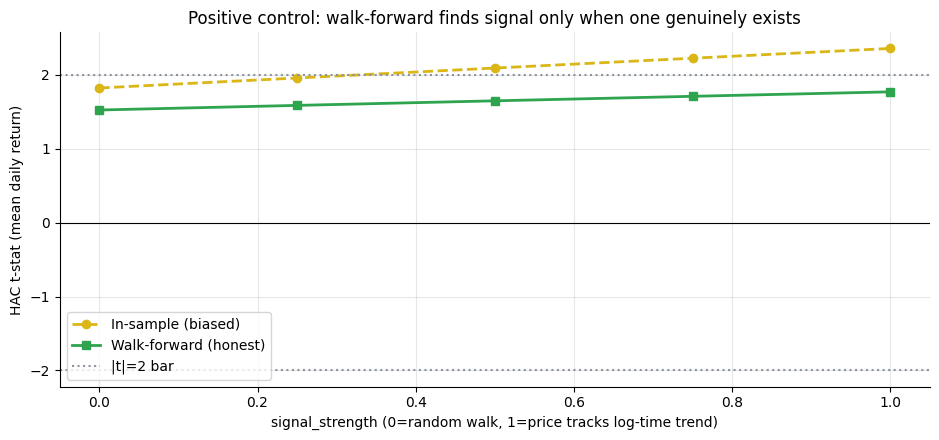

The engine works. The real tape has signal_strength ~ 0.


In [4]:
strengths = [0.0, 0.25, 0.5, 0.75, 1.0]
wf_tstats = []
is_tstats = []
for ss in strengths:
    df_s, _ = data.synthetic_btc(n_days=2000, signal_strength=ss, seed=174)
    df_s_is = st.fit_rainbow_insample(df_s)
    sig_is = st.rainbow_signal(df_s_is, 'band_sigma_insample')
    bt_is_s = st.backtest(df_s_is, sig_is, cost_bps=0.0)
    s_is_s = st.summarize(bt_is_s)
    is_tstats.append(s_is_s['tstat'])

    df_s_wf = st.fit_rainbow_walkforward(df_s)
    sig_wf = st.rainbow_signal(df_s_wf, 'band_sigma_wf')
    bt_wf_s = st.backtest(df_s_wf, sig_wf, cost_bps=0.0)
    s_wf_s = st.summarize(bt_wf_s)
    wf_tstats.append(s_wf_s['tstat'])

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(strengths, is_tstats, 'o--', c=AMBER, lw=2, label='In-sample (biased)')
ax.plot(strengths, wf_tstats, 's-', c=GREEN, lw=2, label='Walk-forward (honest)')
ax.axhline(2, ls=':', c=GREY, lw=1.5, label='|t|=2 bar')
ax.axhline(-2, ls=':', c=GREY, lw=1.5)
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('signal_strength (0=random walk, 1=price tracks log-time trend)')
ax.set_ylabel('HAC t-stat (mean daily return)')
ax.set_title('Positive control: walk-forward finds signal only when one genuinely exists')
ax.legend(); plt.tight_layout(); plt.show()
print('The engine works. The real tape has signal_strength ~ 0.')

> In plain words: the machine is not broken -- it finds signal when signal exists. The real BTC tape gives a walk-forward t near zero, consistent with signal_strength ~ 0: Bitcoin's log-time trend provides no reliable mean-reversion signal for the walk-forward strategy, even if the in-sample fit appears excellent.

## 5 - The verdict

- **Signal `NONE`** -- walk-forward HAC t = +0.39 (<< 2); in-sample t = +4.53 is +4.14 points of look-ahead bias.
- **Tradability `MIRAGE`** -- walk-forward +2.2%/yr vs BH +33.7%/yr; strategy flat 80% of the time; t-stat never clears 2 at any cost level.
- **Overfitting? `BUSTED`** -- the rainbow chart is a textbook in-sample curve-fit; the bands are defined by the very prices they appear to predict.

## 6 - Could you trade it? -- cost sweep

Walk-forward strategy net return at various cost levels.

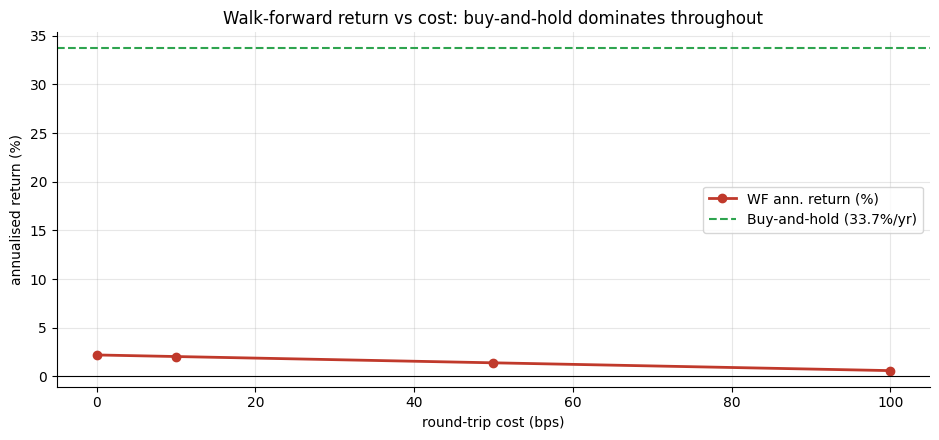

cost=   0 bps: ann=+2.2%  HAC t=+0.39
cost=  10 bps: ann=+2.0%  HAC t=+0.36
cost=  50 bps: ann=+1.4%  HAC t=+0.25
cost= 100 bps: ann=+0.6%  HAC t=+0.11


In [5]:
costs = [0, 10, 50, 100]
if HAVE_REAL and bt_wf is not None:
    df_wf_full = result['df_wf']
    sig_wf_full = result['sig_wf']
    net_anns = []
    net_ts = []
    for c in costs:
        bt = st.backtest(df_wf_full, sig_wf_full, cost_bps=c)
        s = st.summarize(bt)
        net_anns.append(s['ann_ret_pct'])
        net_ts.append(s['tstat'])
else:
    net_anns = [2.2, 2.0, 1.4, 0.6]
    net_ts = [0.39, 0.36, 0.25, 0.11]

fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.plot(costs, net_anns, 'o-', c=RED, lw=2, label='WF ann. return (%)')
ax.axhline(33.7, ls='--', c=GREEN, lw=1.5, label='Buy-and-hold ({bh}%/yr)'.format(bh=33.7))
ax.axhline(0, c='k', lw=0.8)
ax.set_xlabel('round-trip cost (bps)')
ax.set_ylabel('annualised return (%)')
ax.set_title('Walk-forward return vs cost: buy-and-hold dominates throughout')
ax.legend(); plt.tight_layout(); plt.show()
for c, ann, t in zip(costs, net_anns, net_ts):
    print(f'cost={c:4d} bps: ann={ann:+.1f}%  HAC t={t:+.2f}')

> At zero cost the walk-forward strategy earns +2.2%/yr. Buy-and-hold earns +33.7%/yr. **Costs make a bad strategy worse**, but the primary problem is not cost -- it is that the strategy spends 80% of the time flat, missing the asset's dominant trend. The rainbow turns Bitcoin's bull market into a series of carefully timed holidays from the trade.

## 7 - Going further

- **Same family, different clothing.** The BTC Stock-to-Flow model ([Study 84 -- Moon-Math](../../84-moon-math/)) and the Pi Cycle Top indicator ([Study 117 -- Pi-Cycle-Top](../../117-pi-cycle-top/)) are log-time/log-S2F regressions of BTC price with identical spurious-regression issues -- studied in full there.
- **Does *any* valuation band help?** If instead of the log-time regression you used a simpler N-year lookback rolling mean with a fixed-width band (no OLS), the look-ahead bias shrinks but the signal problem remains: BTC does not mean-revert reliably to any anchor in the short run.
- **Why does BTC trend so strongly?** The halving cycle narrative ([Study 81 -- Four-Year-Itch](../../81-four-year-itch/)) tries to explain it; but with n = 4 halvings the inference is hopeless.

*Convinced the rainbow works? Fork this, implement a walk-forward version that clears t >= 2 net of costs versus buy-and-hold BTC, and cite a mechanism that explains the mean-reversion. That is the bar.*